     [Mean] Complete Regression Metrics (Sorted by R2)    
        Feature  R2_Score  P_Value  Coefficient
          B5/B3  0.179201 0.000235    18.192138
(B3-B5)/(B3+B5)  0.174891 0.000284   -16.717748
(B4-B5)/(B4+B5)  0.109522 0.004818    -9.703999
          B5/B7  0.091202 0.010480     1.129841
(B5-B7)/(B5+B7)  0.070711 0.025000     5.772793
(B2-B5)/(B2+B5)  0.067827 0.028269    -2.515368
          B5/B4  0.065450 0.031288     3.029165
(B5-B6)/(B5+B6)  0.055916 0.047102     7.805596
          B6/B7  0.055783 0.047373     4.681099
(B6-B7)/(B6+B7)  0.053007 0.053413     7.990152
          B6/B5  0.052833 0.053817    -5.447610
          B2/B4  0.051369 0.057344    -2.782597
          B2/B5  0.047971 0.066489    -0.138126
          B4/B3  0.047888 0.066731    11.330442
          B5/B6  0.044379 0.077831     1.294815
          B4/B5  0.044164 0.078568    -0.167959
          B7/B5  0.042295 0.085327    -0.735892
          B3/B5  0.040086 0.094110    -0.035670
(B3-B4)/(B3+B4)  0.037730 0.1

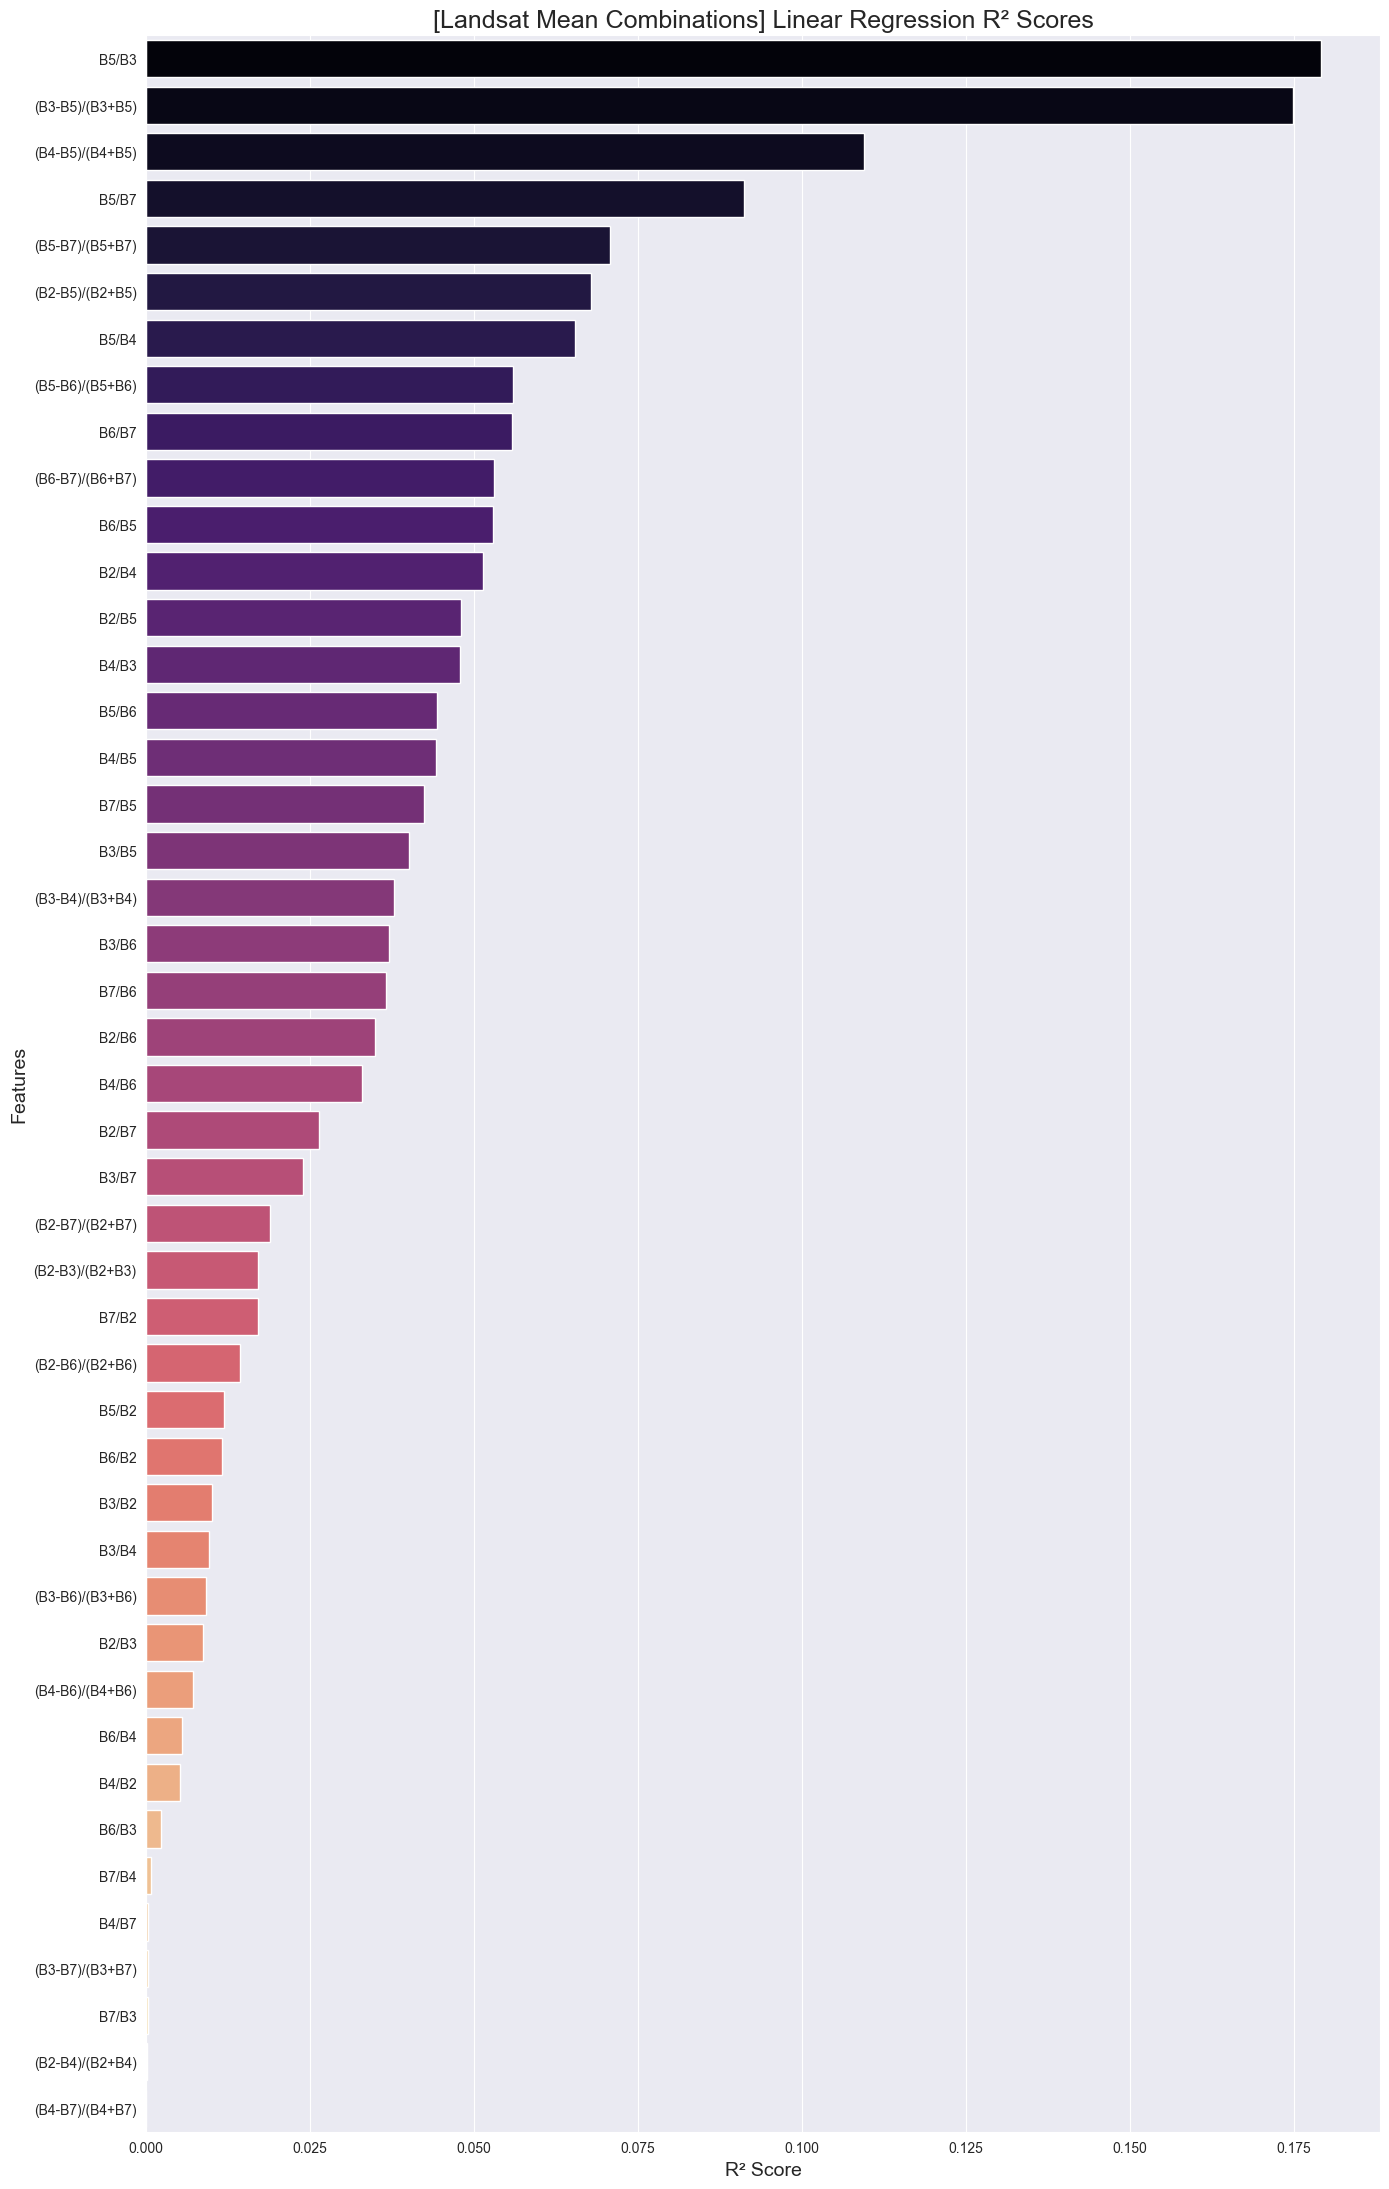

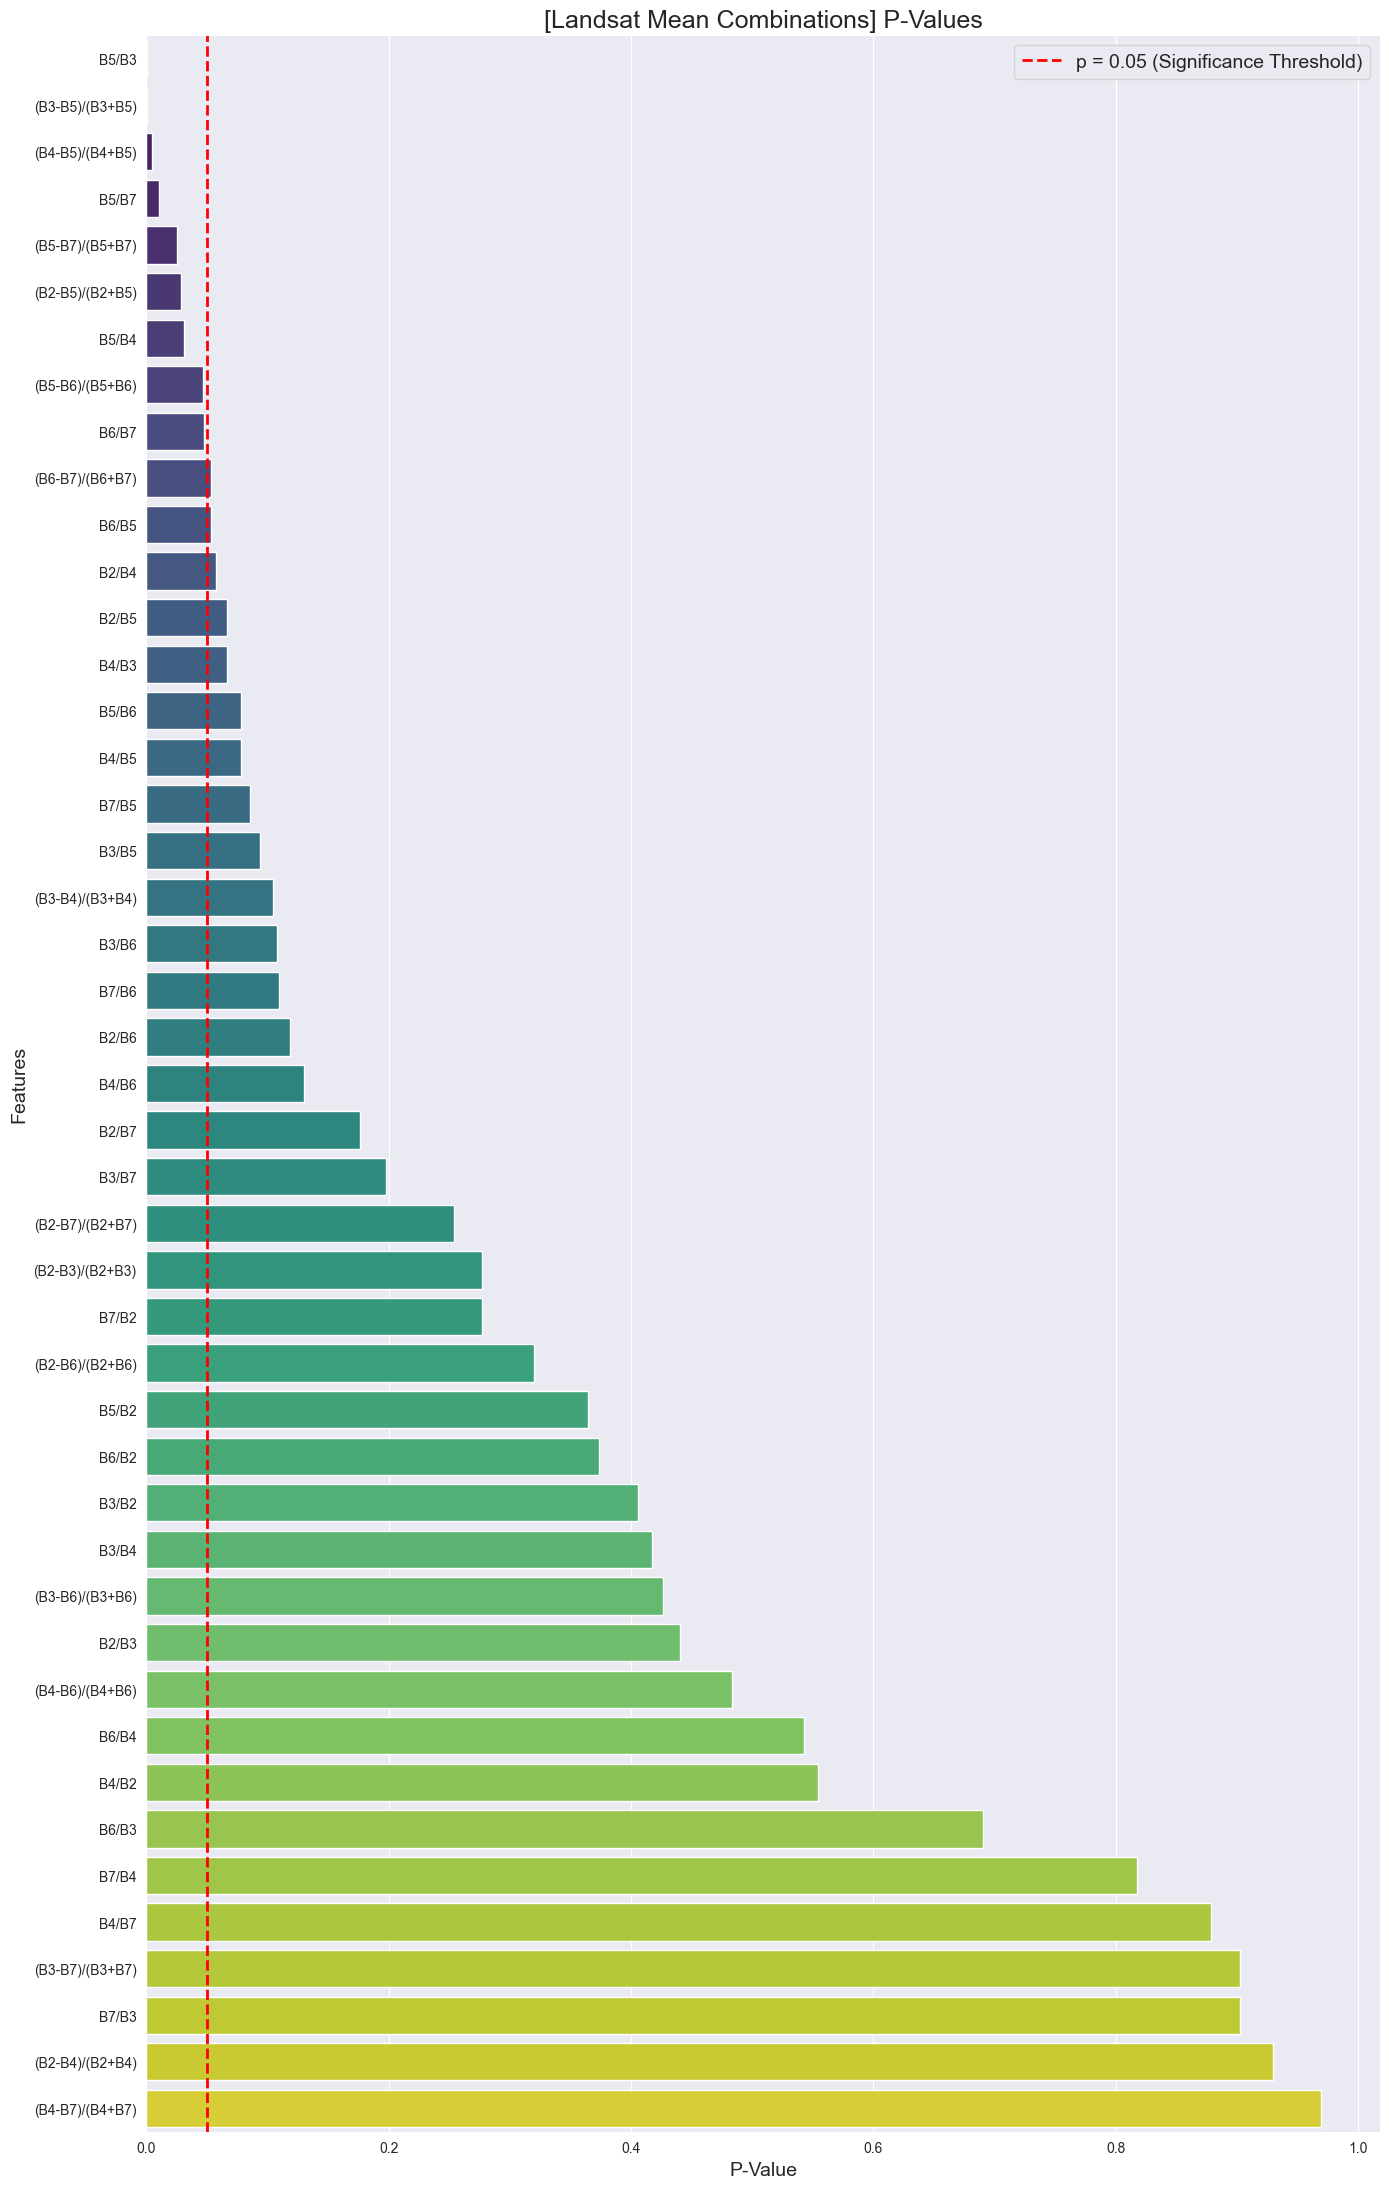

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# --- 1. Load Data ---
file_path = "Landsat89_2024_Combinations 2(Mean_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
start_idx = df.columns.get_loc('B2/B3')
end_idx = df.columns.get_loc('(B6-B7)/(B6+B7)') + 1
feature_cols = df.columns[start_idx:end_idx]

data = df[[target_col] + list(feature_cols)].dropna()
y = data[target_col]

# --- 3. Calculate Regression Metrics (P-Values, R2) ---
results = []
for col in feature_cols:
    X = data[col]
    X = sm.add_constant(X) # Add y-intercept
    model = sm.OLS(y, X).fit()

    results.append({
        'Feature': col,
        'R2_Score': model.rsquared,
        'P_Value': model.pvalues[col],
        'Coefficient': model.params[col]
    })

# Combine into one DataFrame and sort by highest R2 Score
results_df = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("     [Mean] Complete Regression Metrics (Sorted by R2)    ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting ---

# Plot 1: R2 Score
plt.figure(figsize=(14, 22))
sns.barplot(x='R2_Score', y='Feature', data=results_df, palette='magma', hue='Feature', legend=False)
plt.title('[Landsat Mean Combinations] Linear Regression R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: P-Values
plt.figure(figsize=(14, 22))
# Sort by lowest p-value (most statistically significant)
pval_sorted = results_df.sort_values(by='P_Value', ascending=True)
sns.barplot(x='P_Value', y='Feature', data=pval_sorted, palette='viridis', hue='Feature', legend=False)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05 (Significance Threshold)')
plt.title('[Landsat Mean Combinations] P-Values', fontsize=18)
plt.xlabel('P-Value', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Export to Excel
results_df.to_excel("Landsat_Mean_Regression_Results.xlsx", index=False)

    [Median] Complete Regression Metrics (Sorted by R2)   
        Feature  R2_Score  P_Value  Coefficient
          B5/B3  0.185131 0.000180    18.467059
(B3-B5)/(B3+B5)  0.177679 0.000251   -16.753093
(B4-B5)/(B4+B5)  0.114348 0.003924    -9.696499
          B5/B7  0.082267 0.015304     1.047481
(B5-B7)/(B5+B7)  0.066993 0.029293     5.319654
          B5/B4  0.063050 0.034669     2.706162
          B6/B7  0.055047 0.048903     4.551354
(B6-B7)/(B6+B7)  0.053759 0.051701     7.784127
          B2/B4  0.048074 0.066191    -2.208411
(B2-B5)/(B2+B5)  0.046274 0.071613    -1.102156
          B4/B3  0.046092 0.072187    11.149100
          B3/B6  0.040734 0.091439    -0.024758
          B7/B6  0.040211 0.093590    -0.515114
          B5/B6  0.039522 0.096505     1.169133
          B2/B6  0.037964 0.103462    -0.064948
          B4/B6  0.037272 0.106725    -0.096323
(B3-B4)/(B3+B4)  0.035729 0.114400   -10.484030
          B2/B7  0.028895 0.156416    -0.431346
(B5-B6)/(B5+B6)  0.026858 0.1

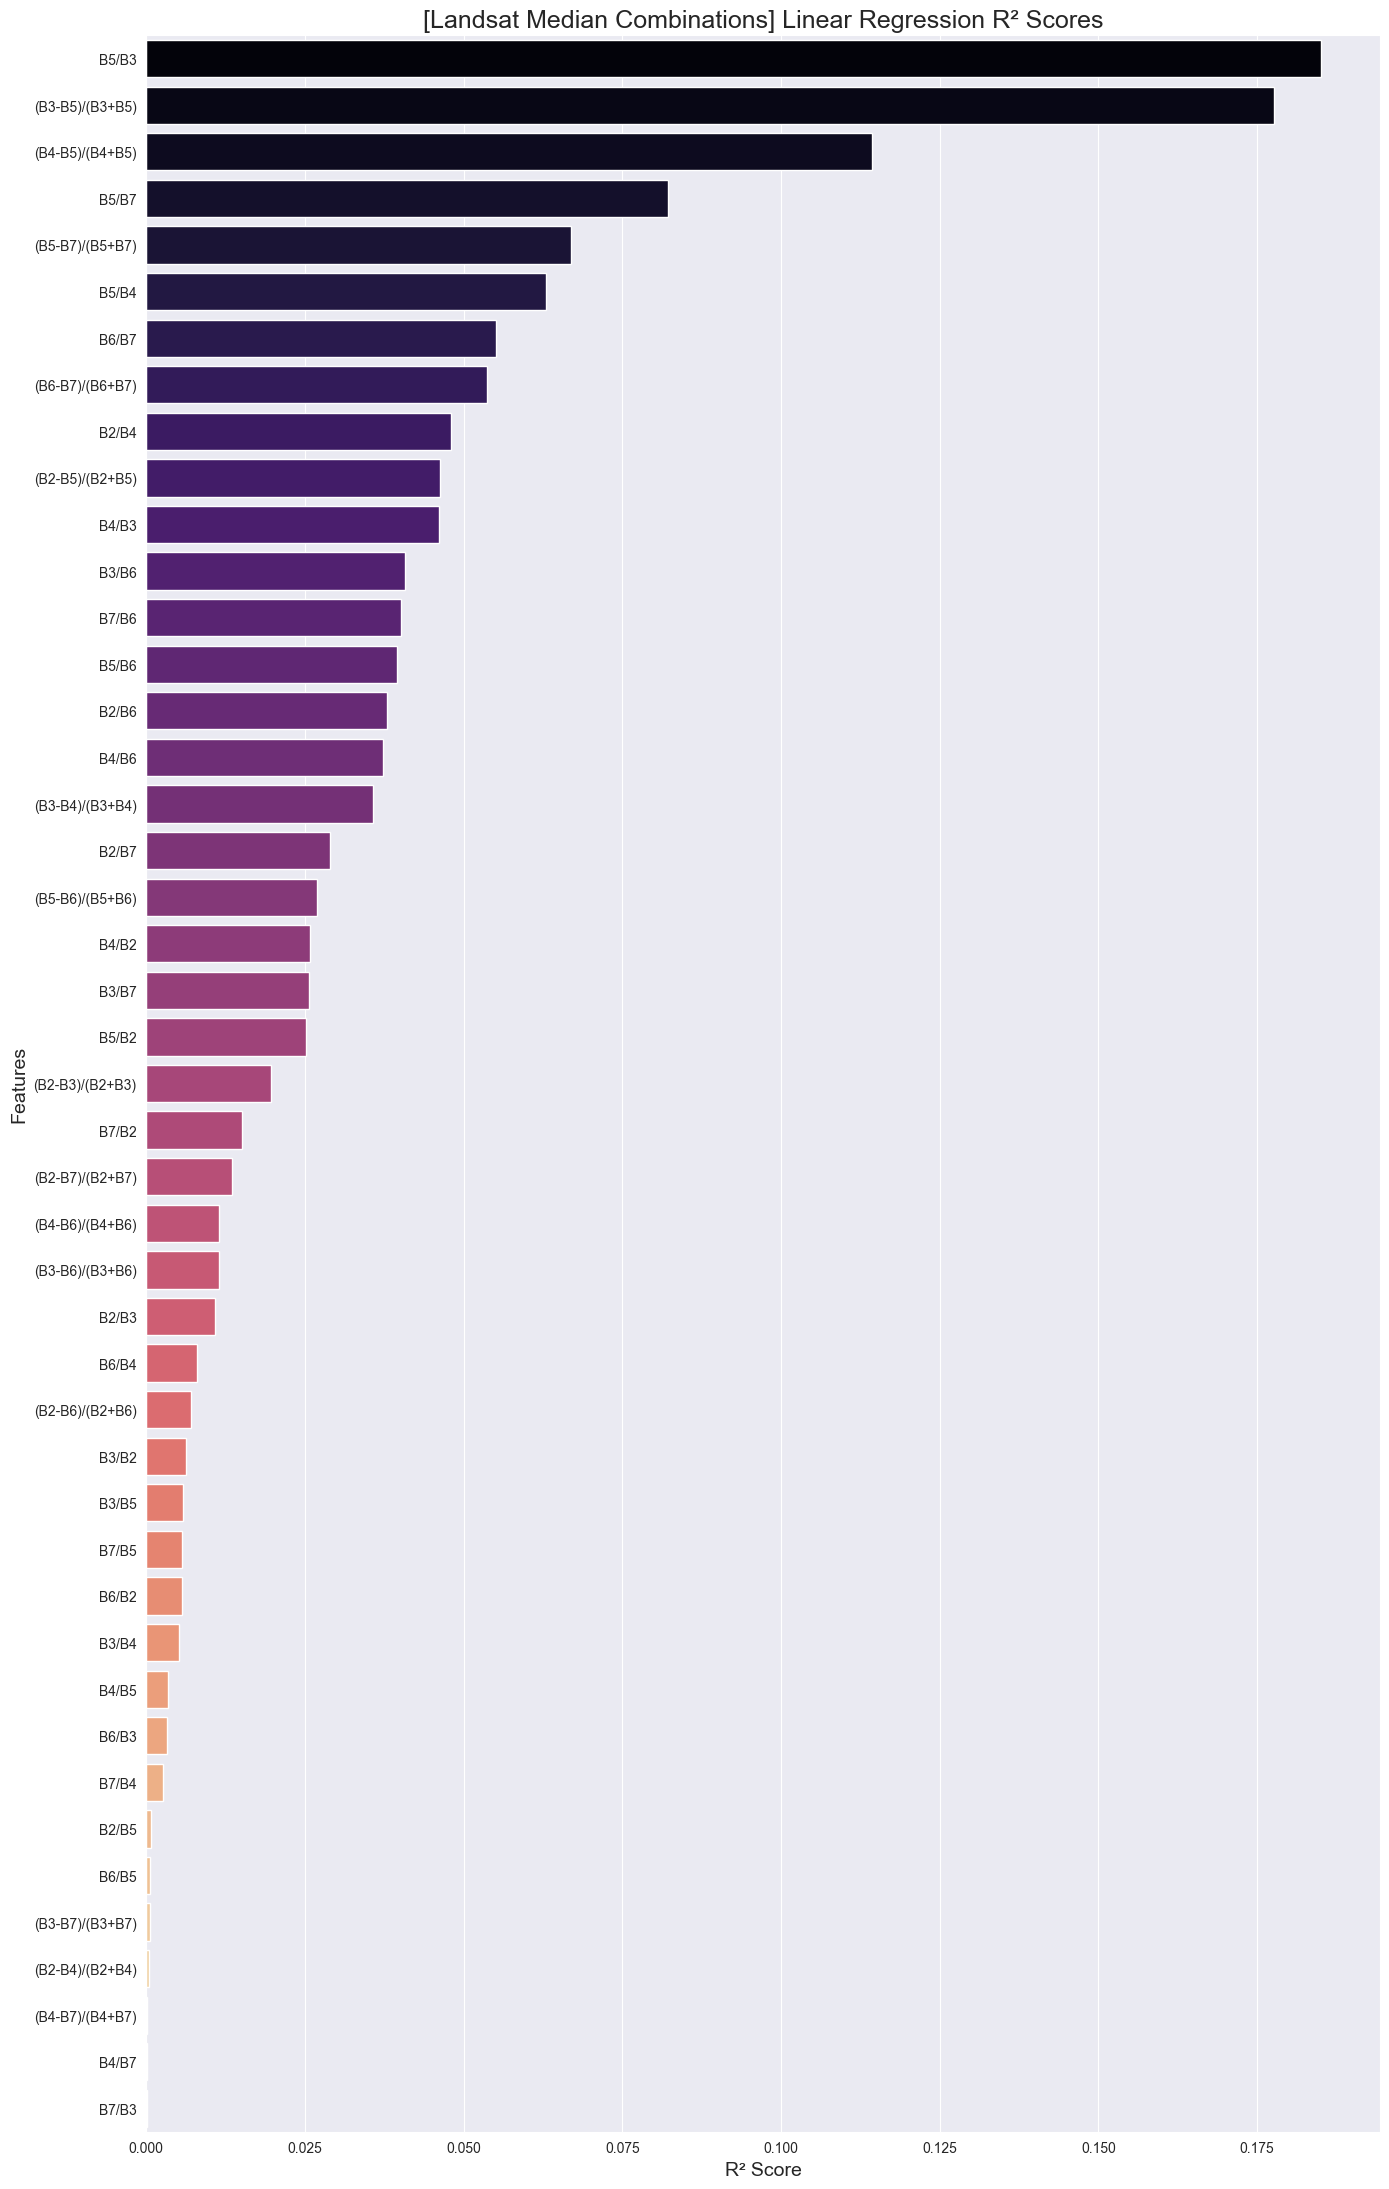

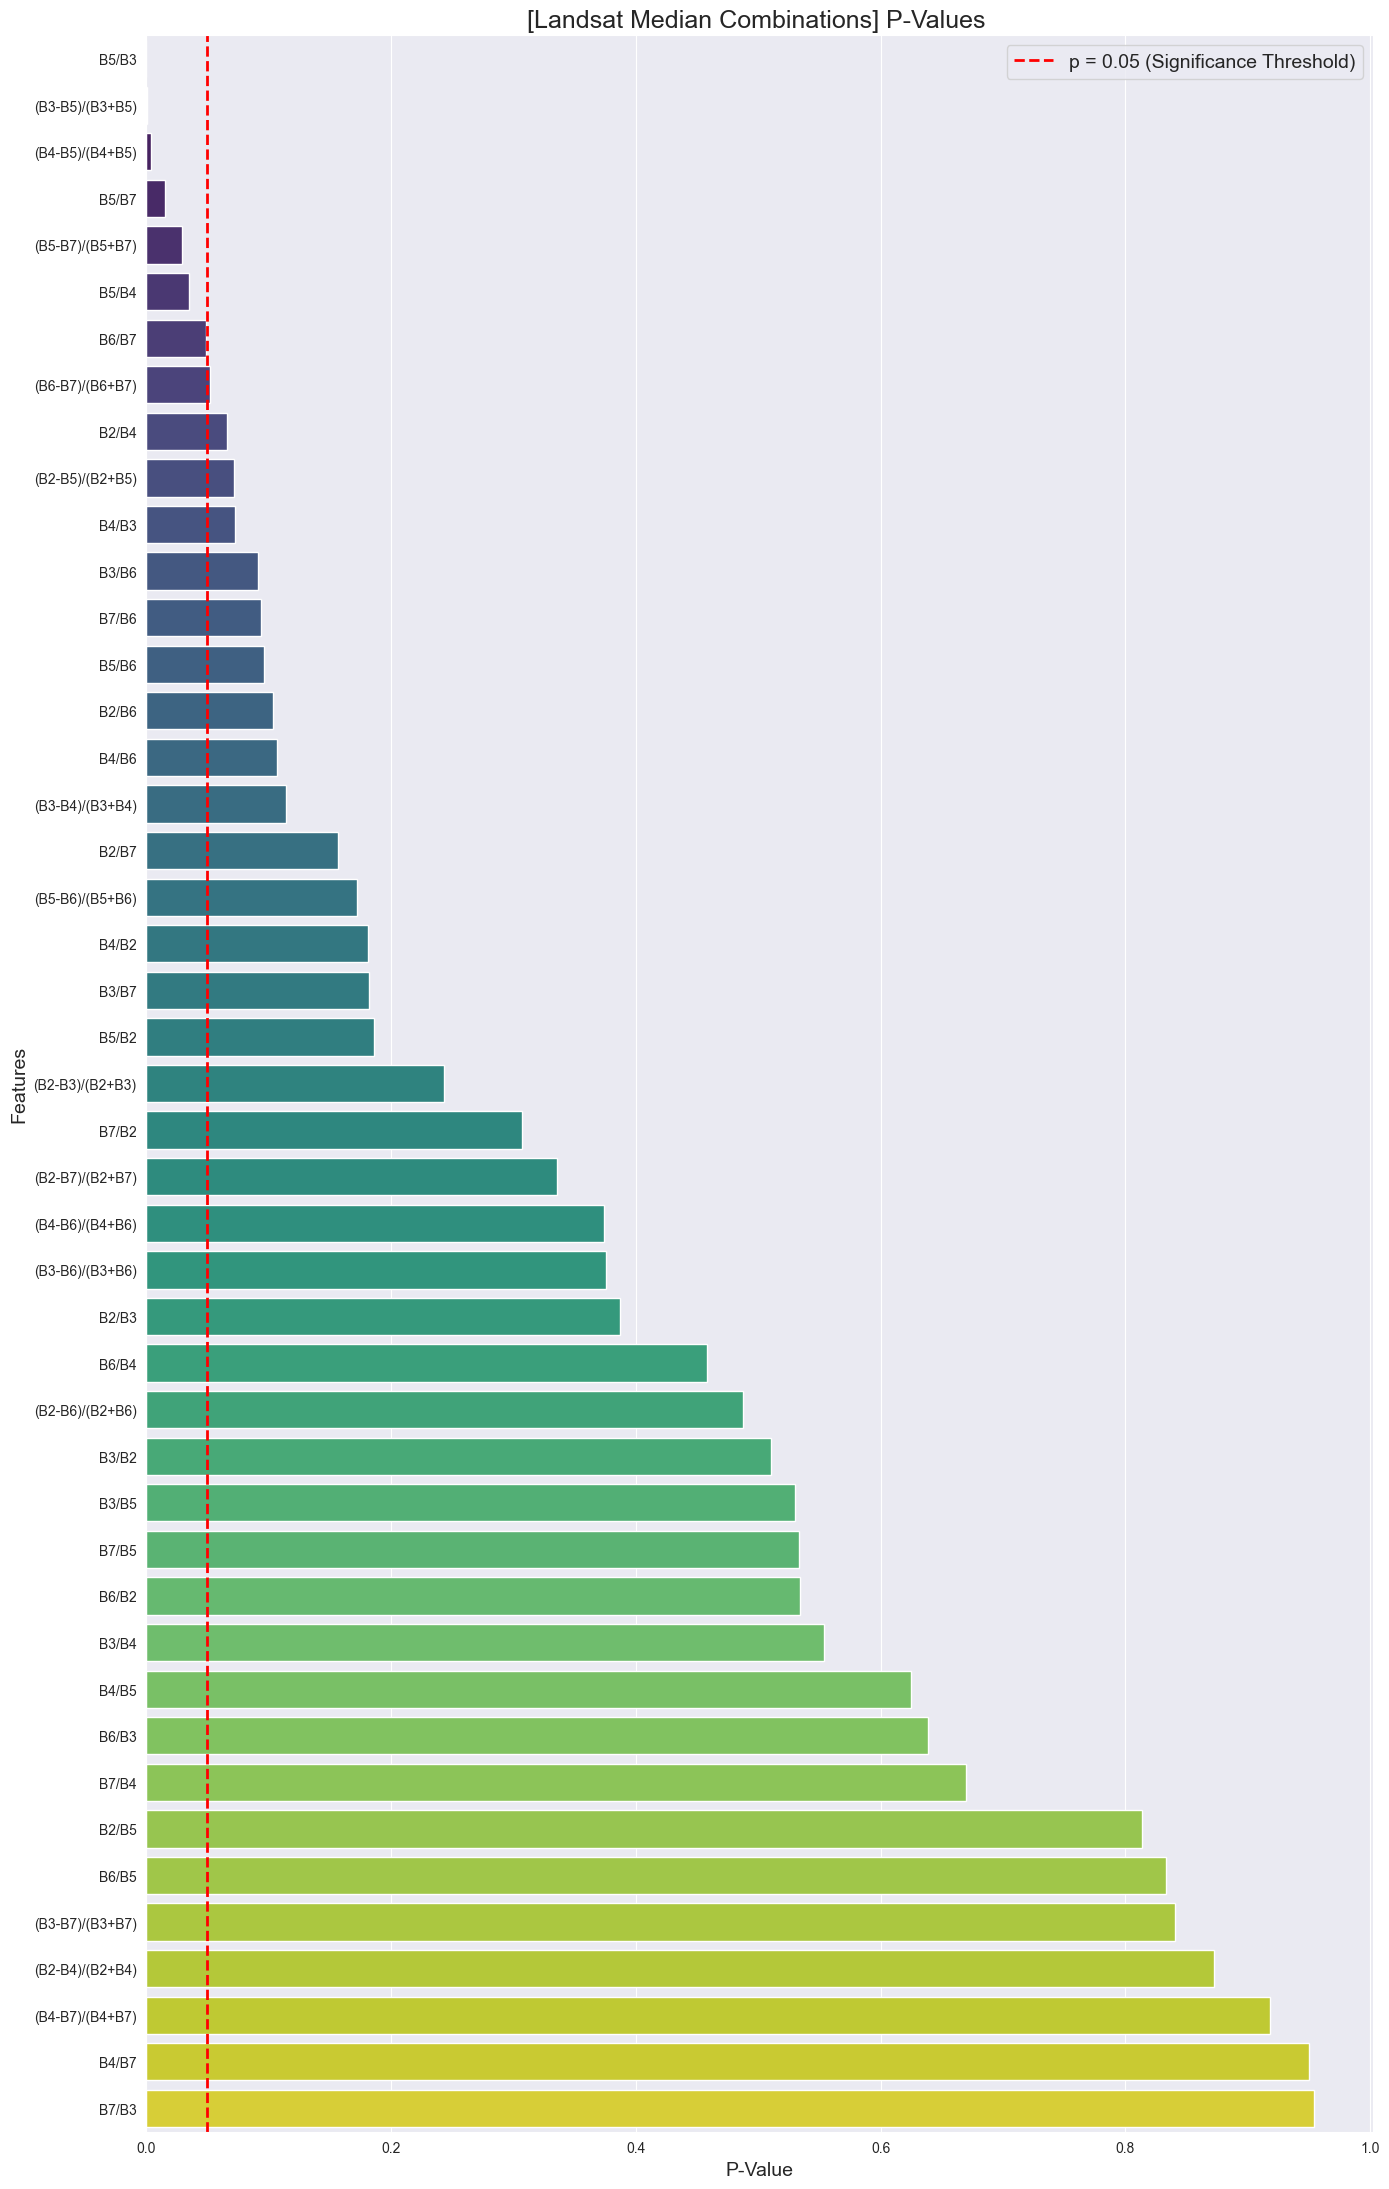

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# --- 1. Load Data ---
file_path = "Landsat89_2024_Combinations 2(Median_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
start_idx = df.columns.get_loc('B2/B3')
end_idx = df.columns.get_loc('(B6-B7)/(B6+B7)') + 1
feature_cols = df.columns[start_idx:end_idx]

data = df[[target_col] + list(feature_cols)].dropna()
y = data[target_col]

# --- 3. Calculate Regression Metrics ---
results = []
for col in feature_cols:
    X = data[col]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    results.append({
        'Feature': col,
        'R2_Score': model.rsquared,
        'P_Value': model.pvalues[col],
        'Coefficient': model.params[col]
    })

results_df = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("    [Median] Complete Regression Metrics (Sorted by R2)   ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting ---

# Plot 1: R2 Score
plt.figure(figsize=(14, 22))
sns.barplot(x='R2_Score', y='Feature', data=results_df, palette='magma', hue='Feature', legend=False)
plt.title('[Landsat Median Combinations] Linear Regression R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: P-Values
plt.figure(figsize=(14, 22))
pval_sorted = results_df.sort_values(by='P_Value', ascending=True)
sns.barplot(x='P_Value', y='Feature', data=pval_sorted, palette='viridis', hue='Feature', legend=False)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05 (Significance Threshold)')
plt.title('[Landsat Median Combinations] P-Values ', fontsize=18)
plt.xlabel('P-Value', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Export to Excel
results_df.to_excel("Landsat_Median_Regression_Results.xlsx", index=False)

      [SD] Complete Regression Metrics (Sorted by R2)     
        Feature     R2_Score  P_Value  Coefficient
          B7/B6 3.503781e-02 0.135418     0.795455
          B5/B2 3.051851e-02 0.163971     2.018556
          B3/B7 2.602621e-02 0.199196    -0.061948
          B2/B4 2.484846e-02 0.209812    -0.935252
(B3-B4)/(B3+B4) 2.426116e-02 0.215350    -4.012689
          B3/B6 2.336712e-02 0.224111    -0.107764
          B2/B6 2.177628e-02 0.240763    -0.070726
(B2-B5)/(B2+B5) 2.034629e-02 0.257005    -3.076934
(B2-B4)/(B2+B4) 1.742514e-02 0.294547    -3.430188
          B2/B7 1.734444e-02 0.295678    -0.032517
          B7/B2 1.678087e-02 0.303729     1.607887
          B4/B7 1.609123e-02 0.313965    -0.057225
(B2-B7)/(B2+B7) 1.564890e-02 0.320763    -2.503304
          B3/B5 1.267579e-02 0.371892    -0.000003
          B6/B5 1.267571e-02 0.371894    -0.000006
          B4/B5 1.267554e-02 0.371897    -0.000004
          B2/B5 1.267548e-02 0.371898    -0.000005
          B7/B5 1.26752

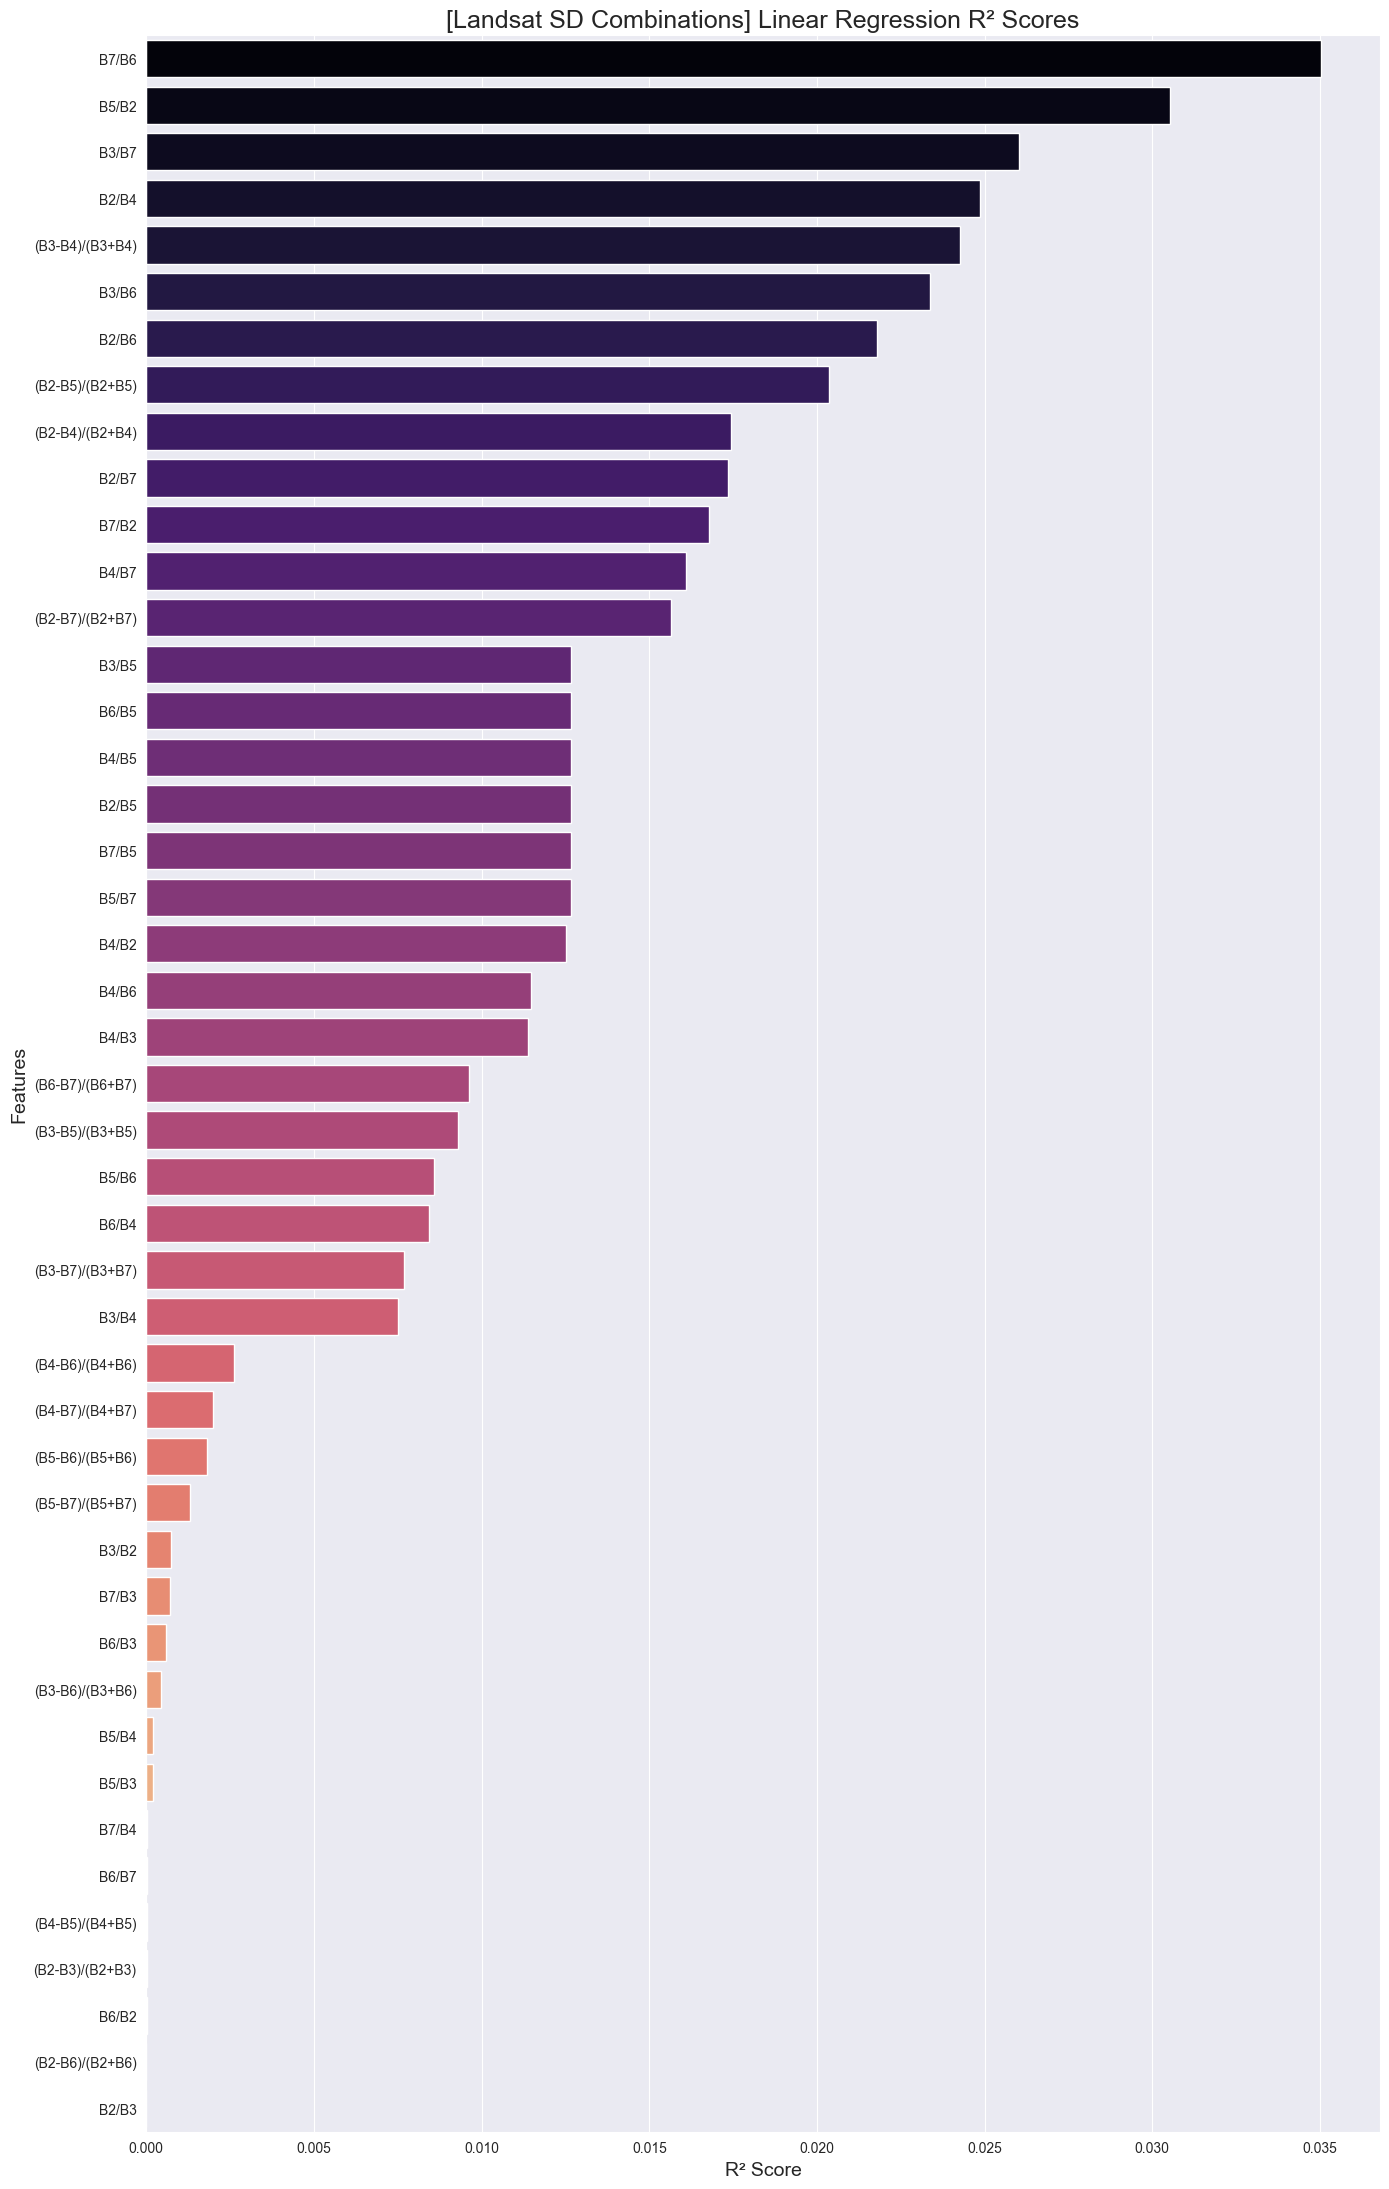

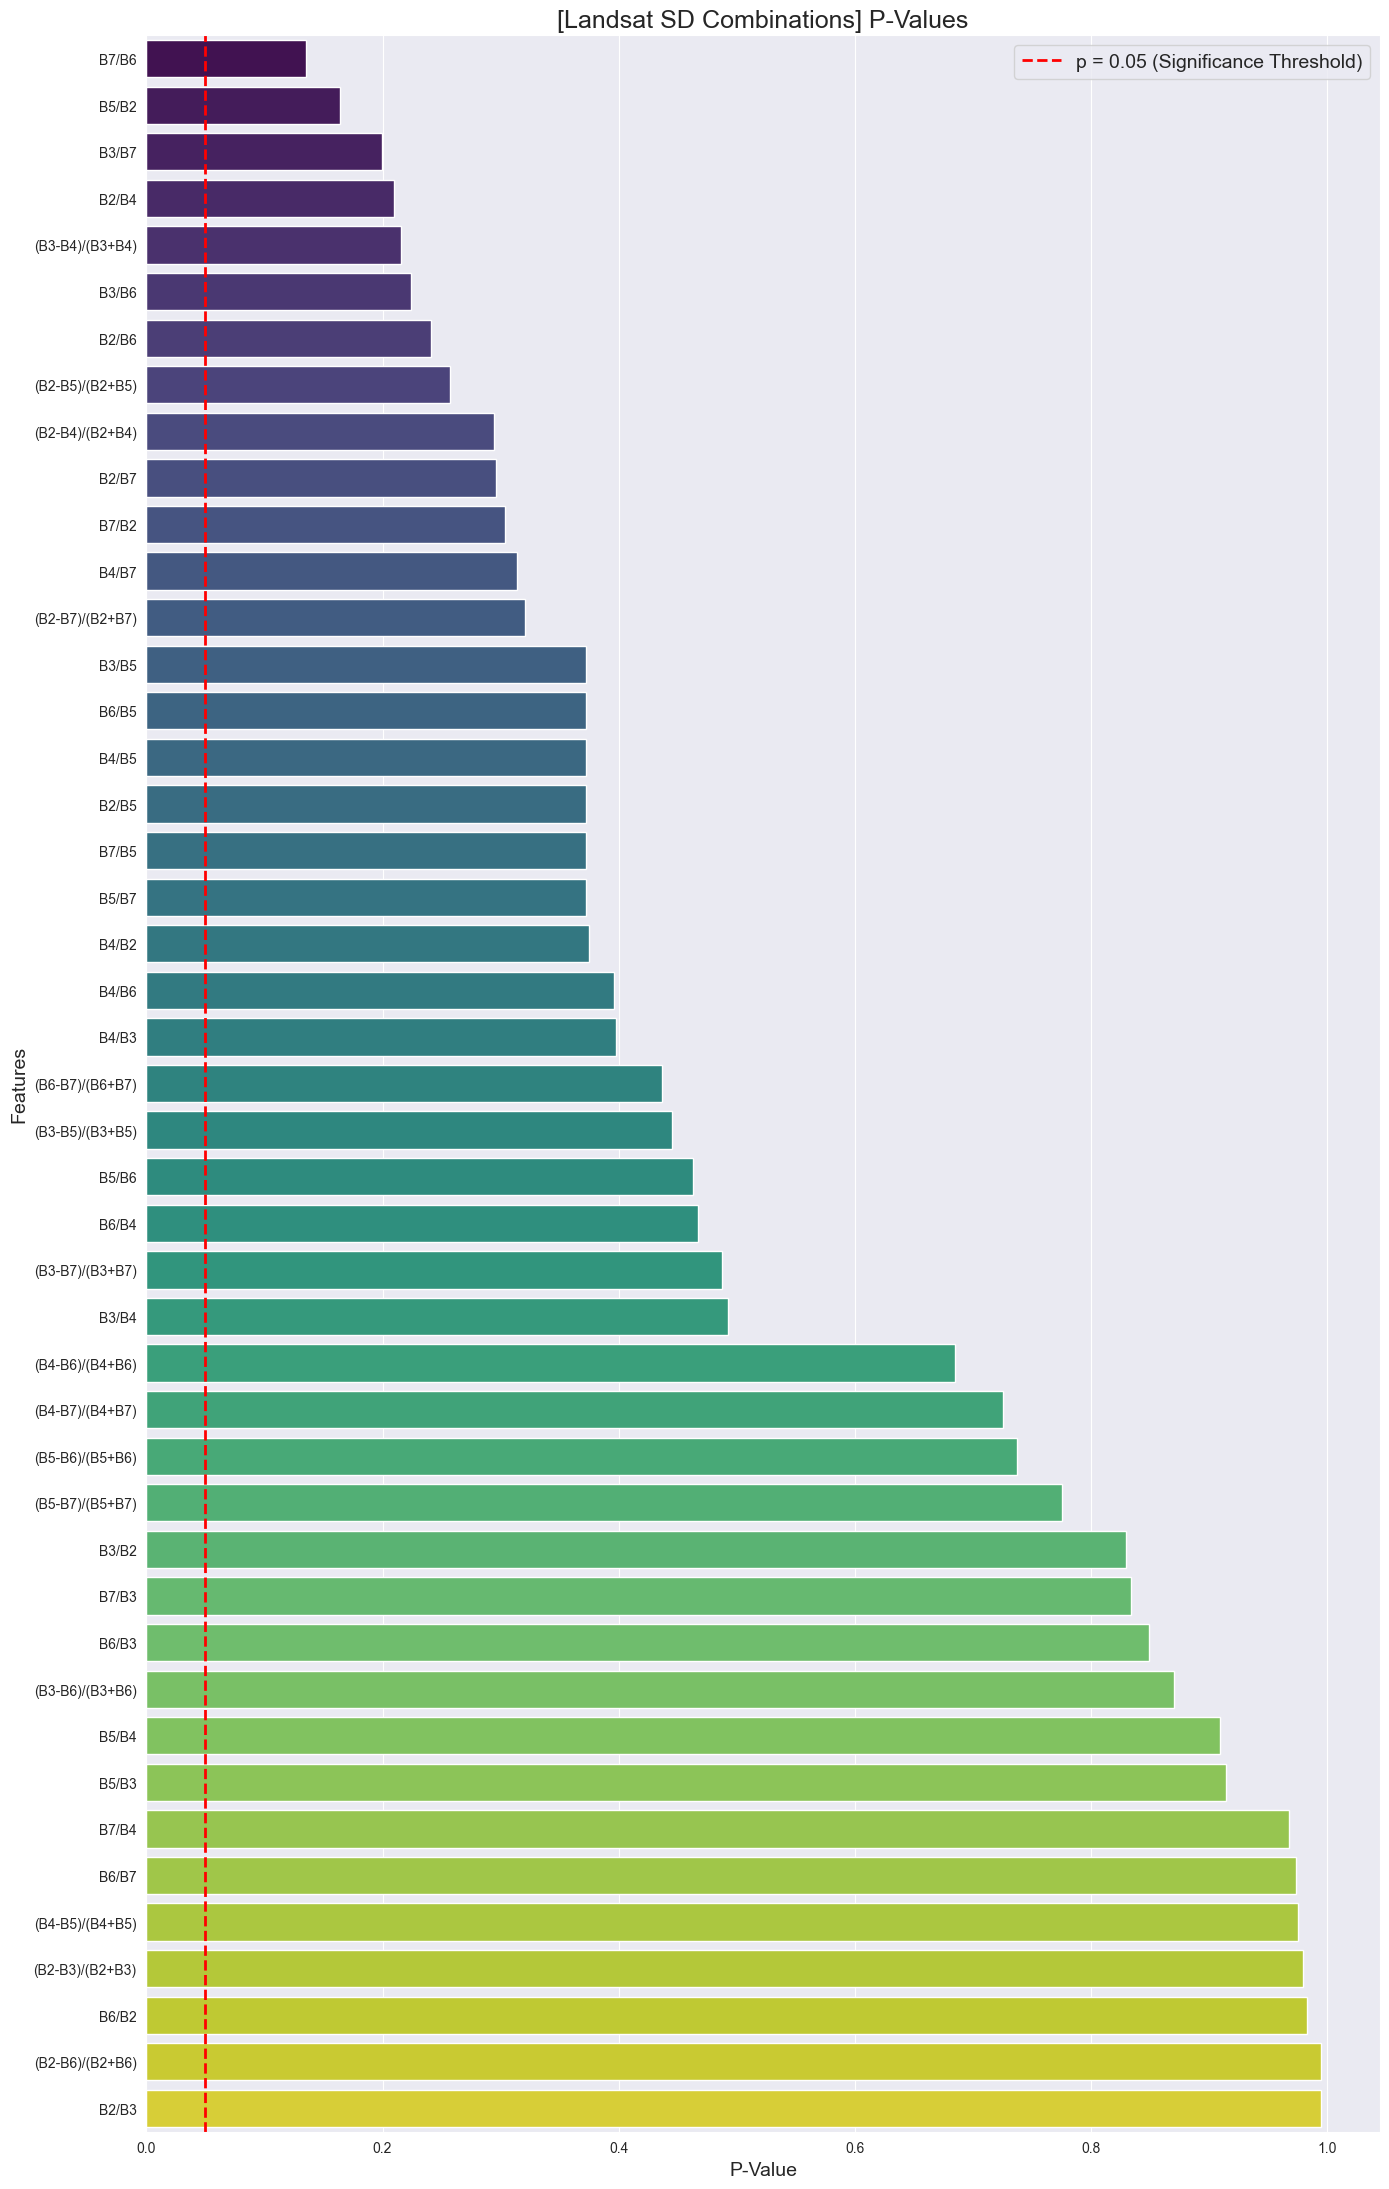

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# --- 1. Load Data ---
file_path = "Landsat89_2024_Combinations 2(SD_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
start_idx = df.columns.get_loc('B2/B3')
end_idx = df.columns.get_loc('(B6-B7)/(B6+B7)') + 1
feature_cols = df.columns[start_idx:end_idx]

data = df[[target_col] + list(feature_cols)].dropna()
y = data[target_col]

# --- 3. Calculate Regression Metrics ---
results = []
for col in feature_cols:
    X = data[col]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    results.append({
        'Feature': col,
        'R2_Score': model.rsquared,
        'P_Value': model.pvalues[col],
        'Coefficient': model.params[col]
    })

results_df = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("      [SD] Complete Regression Metrics (Sorted by R2)     ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting ---

# Plot 1: R2 Score
plt.figure(figsize=(14, 22))
sns.barplot(x='R2_Score', y='Feature', data=results_df, palette='magma', hue='Feature', legend=False)
plt.title('[Landsat SD Combinations] Linear Regression R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: P-Values
plt.figure(figsize=(14, 22))
pval_sorted = results_df.sort_values(by='P_Value', ascending=True)
sns.barplot(x='P_Value', y='Feature', data=pval_sorted, palette='viridis', hue='Feature', legend=False)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05 (Significance Threshold)')
plt.title('[Landsat SD Combinations] P-Values', fontsize=18)
plt.xlabel('P-Value', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Export to Excel
results_df.to_excel("Landsat_SD_Regression_Results.xlsx", index=False)